In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
import sirf.Utilities
import sirf.Reg as Reg
import numpy as np
import stir
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
import numexpr as ne
ne.set_num_threads(16) # use only 16 threads
import shutil
import json
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")

CREATE VIRTUAL PHANTOMS

In [20]:
matrix_size = (256,) * 3
voxel_size = (2.21,) * 3

# Lu-177 NEMA SPECT phantom
print("Creating Lu-177 SPECT NEMA phantom and attenuation map...")
earl_nema_dict_lu177 = {
    "mu_values":{
        "perspex_mu_value": 0.15,
        "fill_mu_value": 0.14,
        "lung_mu_value": 0.043
    },
    "activity_concentration_background": 0.0,
    "include_lung_insert": False,
    "sphere_dict": {
        "ring_R": 57,
        "ring_z": -37,
        "spheres": {
            "diametre_mm": [13,17,22,28,37,60],
            "angle_loc":   [270,150,30,90,330,210],
            "act_conc_MBq_ml": [1.611,1.611,1.611,1.611,1.611,1.611],
        }
    }
}

nema_act_lu_arr, nema_ctac_lu_arr, mask_lu_dict= phantom.create_nema(
    matrix_size=matrix_size, 
    voxel_size_mm=voxel_size, 
    nema_dict=earl_nema_dict_lu177,
    supersample=3
    )

nema_act_lu = spect.ImageData()
nema_act_lu.initialise(dim=matrix_size,vsize=voxel_size)
nema_act_lu.fill(nema_act_lu_arr)
source_lu_dir = demo_path / "simind_data" / "lu177_256" / "input"
source_lu_dir.mkdir(parents=True, exist_ok=True)
nema_act_lu.write(str(source_lu_dir / "nema_lu_act"))

nema_ctac_lu = nema_act_lu.clone()
nema_ctac_lu.fill(nema_ctac_lu_arr)
nema_ctac_lu.write(str(source_lu_dir / "nema_lu_ctac"))

np.savez_compressed(str(source_lu_dir / "masks_lu.npz"), **mask_lu_dict)

print()

# Tc-99m NEMA SPECT phantom
print("Creating Tc-99m SPECT NEMA phantom and attenuation map...")
earl_nema_dict_tc99m = {
    "mu_values":{
        "perspex_mu_value": 0.175,
        "fill_mu_value": 0.154,
        "lung_mu_value": 0.046
    },
    "activity_concentration_background": 0.0,
    "include_lung_insert": False,
    "sphere_dict": {
        "ring_R": 57,
        "ring_z": -37,
        "spheres": {
            "diametre_mm": [13,17,22,28,37,60],
            "angle_loc":   [270,150,30,90,330,210],
            "act_conc_MBq_ml": [1.013,1.013,1.013,1.013,1.013,1.013],
        }
    }
}

nema_act_tc_arr, nema_ctac_tc_arr, mask_tc_dict= phantom.create_nema(
    matrix_size=matrix_size, 
    voxel_size_mm=voxel_size, 
    nema_dict=earl_nema_dict_tc99m,
    supersample=3
    )

nema_act_tc = spect.ImageData()
nema_act_tc.initialise(dim=matrix_size,vsize=voxel_size)
nema_act_tc.fill(nema_act_tc_arr)
source_tc_dir = demo_path / "simind_data" / "tc99m_256" / "input"
source_tc_dir.mkdir(parents=True, exist_ok=True)
nema_act_tc.write(str(source_tc_dir / "nema_tc_act"))

nema_ctac_tc = nema_act_tc.clone()
nema_ctac_tc.fill(nema_ctac_tc_arr)
nema_ctac_tc.write(str(source_tc_dir / "nema_tc_ctac"))

np.savez_compressed(str(source_tc_dir / "masks_tc.npz"), **mask_tc_dict)


Creating Lu-177 SPECT NEMA phantom and attenuation map...



Creating Tc-99m SPECT NEMA phantom and attenuation map...


(<Figure size 600x500 with 2 Axes>, <Axes: >)

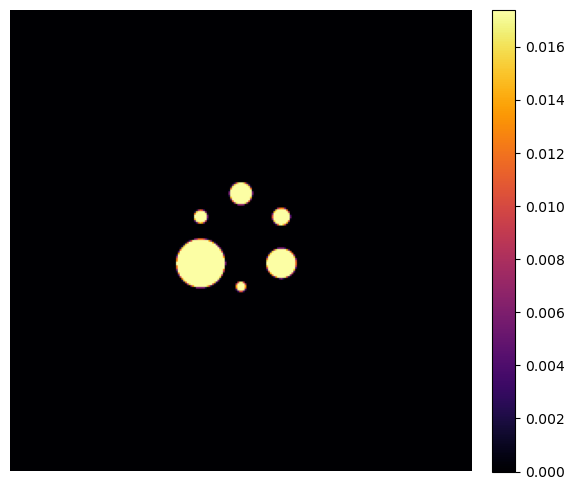

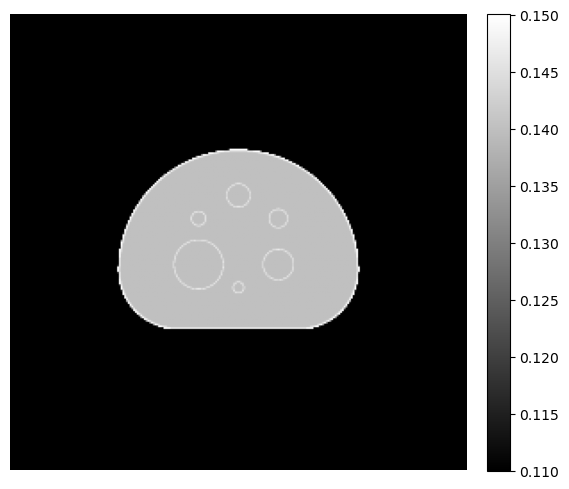

In [22]:
idx = (110,slice(None),slice(None))

utils.display_arr(
    arr_3d=nema_act_lu_arr,
    idx=idx
)

utils.display_arr(
    arr_3d=nema_ctac_lu_arr,
    idx=idx,
    cmap="gray",
    vmin=0.11
)


RUN SIMULATION FOR Tc99m

In [23]:
# for Tc99m

# -------------------------------------------------------------------------
# Define energy window
#
# Example: ±10% photopeak window around 140 keV
# 126–154 keV
#
# scatter_orders = 0 means all scatter orders are accepted by SCATTWIN.
# -------------------------------------------------------------------------

window_lower = [114.0, 126.45]  # 140 - 14 keV
window_upper = [126.0, 154.55]  # 140 + 14 keV
scatter_orders = [0,] * len(window_upper)

config_file = demo_path / "Discovery670_tc99m.yaml"

output_tc_dir = demo_path / "simind_data" / "tc99m_256" / "output"
output_tc_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "tc99m_simulation"

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_tc_dir),
    output_prefix=output_prefix,
    photon_multiplier=0.1,
)


# Set source and attenuation map

simind.set_source(nema_act_tc)
simind.set_mu_map(nema_ctac_tc)


# Set energy windows

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)



# SIMIND runtime settings

# Tc-99m radionuclide data
simind.add_runtime_switch("FI", "tc99m")

# Discovery 670 collimator.
# Your YAML contains "ge-megp" as text variable 1.
simind.add_runtime_switch("CC", "ge-megp")

# Random seed
simind.add_runtime_switch("RR", 12345)


# -------------------------------------------------------------------------
# Run SIMIND
# -------------------------------------------------------------------------

outputs = simind.run()



INFO: Running SIMIND: simind tc99m_simulation tc99m_simulation /NN:0.1/FI:tc99m/CC:ge-megp/RR:12345/PX:0.22100000381469725


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: tc99m_simulation  
 Phantom B : bone      BackScatt.: pmt       OutputFile: tc99m_simulation  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: tc99m_simulation_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: tc99m_simulation_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 140          tc99m     PhotonsPerProj....: 743068         
 EnergyResolution...: 12           Spectra   Activity..........: 3249.5         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 210          x-rays    Distance to det...: 16.91          
 LowerEneWindowTresh: 70           Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w1.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_air_w2.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_sca_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simulation_sca_w1.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output/tc99m_simu

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 0.5                    CutoffEnergy......: 0              
 Photons/Bq.........: 0.88524                StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 256                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 256                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 3871.23665     
 NN ScalingFactor...: 0.1                    Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

In [25]:
output_tc_dir = Path("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_256/output")
output_prefix = "tc99m_simulation"

pp_path = output_tc_dir / f"{output_prefix}_tot_w2.hs"
sc_path = output_tc_dir / f"{output_prefix}_tot_w1.hs"

tomo_tc_dir = demo_path / "simind_data" / "tc99m_256" / "tomo"
tomo_tc_dir.mkdir(parents=True, exist_ok=True)

pp_path_noisy = tomo_tc_dir / f"{output_prefix}_em_noisy.hs"
sc_path_noisy = tomo_tc_dir / f"{output_prefix}_sc_noisy.hs"

utils.acq_poisson_noise(
    hs_file=pp_path,
    save_path=pp_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc_path,
    save_path=sc_path_noisy
)

acq_tc_dew = utils.scatter_correction(
    PP_hdr=str(pp_path_noisy),
    SC1_hdr=str(sc_path_noisy)
)

dew_path = tomo_tc_dir / f"{output_prefix}_dew.hs"
acq_tc_dew.write(str(dew_path)[:-3])

Photopeak window width: 28.1
Scatter window width: 12.0
Scatter fraction: 1.17


(<Figure size 600x500 with 2 Axes>, <Axes: title={'center': 'Tc99m DEW'}>)

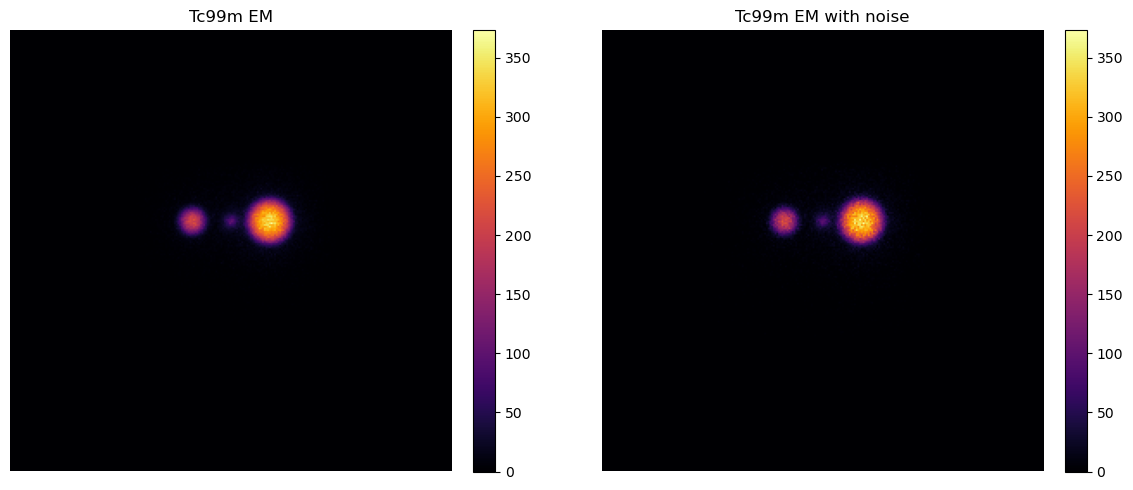

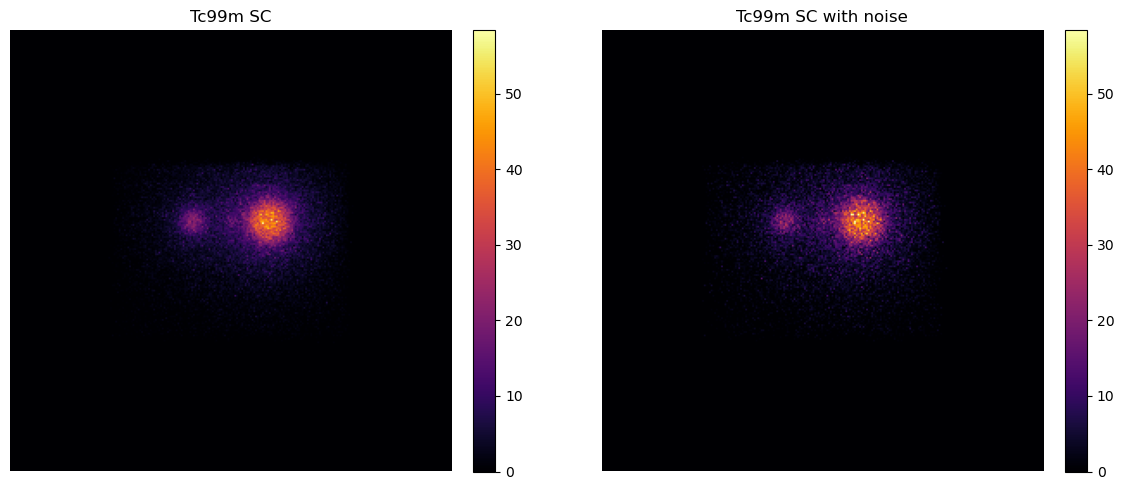

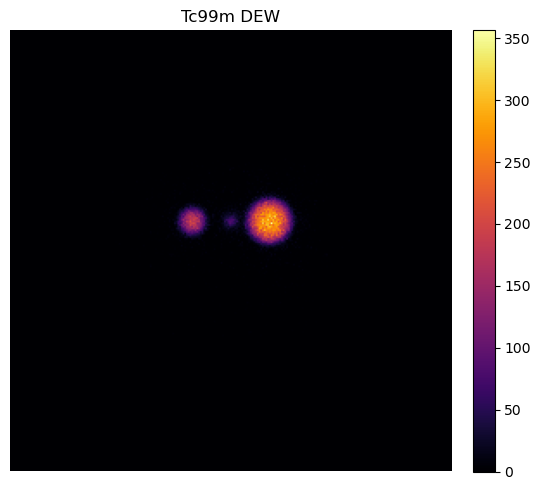

In [26]:
idx = (slice(None), 60, slice(None))
vmax = np.max(spect.AcquisitionData(str(pp_path)).as_array()[0,:])

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(pp_path)).as_array()[0,:], spect.AcquisitionData(str(pp_path_noisy)).as_array()[0,:]],
    idx=idx,
    titles=["Tc99m EM", "Tc99m EM with noise"],
    vmax=[vmax, vmax],
    vmin =[0, 0]
)

vmax = np.max(spect.AcquisitionData(str(sc_path)).as_array()[0,:])
utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc_path)).as_array()[0,:], spect.AcquisitionData(str(sc_path_noisy)).as_array()[0,:]],
    idx=idx,
    titles=["Tc99m SC", "Tc99m SC with noise"],
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=spect.AcquisitionData(str(dew_path)).as_array()[0,:],
    idx=idx,
    titles="Tc99m DEW"
)

In [28]:
# for Lu177m

# -------------------------------------------------------------------------
# Define energy window
#
# Example: ±10% photopeak window around 208 keV
# 187.2–228.8 keV
#
# scatter_orders = 0 means all scatter orders are accepted by SCATTWIN.
# -------------------------------------------------------------------------

window_lower = [187.2, 156.4, 229.36] # keV
window_upper = [228.8, 183.6, 258.64] # keV
scatter_orders = [0,] * len(window_upper)

config_file = demo_path / "Discovery670_lu177.yaml"

output_lu_dir = demo_path / "simind_data" / "lu177_256" / "output"
output_lu_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "lu177_simulation"

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_lu_dir),
    output_prefix=output_prefix,
    photon_multiplier=0.1,
)


# Set source and attenuation map

simind.set_source(nema_act_lu)
simind.set_mu_map(nema_ctac_lu)


# Set energy windows

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)



# SIMIND runtime settings

# Lu-177 radionuclide data
simind.add_runtime_switch("FI", "lu177")

# Discovery 670 collimator.
# Your YAML contains "ge-megp" as text variable 1.
simind.add_runtime_switch("CC", "ge-megp")

# Random seed
simind.add_runtime_switch("RR", 12345)


# -------------------------------------------------------------------------
# Run SIMIND
# -------------------------------------------------------------------------

outputs = simind.run()



INFO: Running SIMIND: simind lu177_simulation lu177_simulation /NN:0.1/FI:lu177/CC:ge-megp/RR:12345/PX:0.22100000381469725


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_simulation  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_simulation  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_simulation_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_simulation_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 743068         
 EnergyResolution...: 12           Spectra   Activity..........: 11110          
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 16.91          
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w2.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w3.h00 to /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simulation_air_w3.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output/lu177_simu

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 256                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 256                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 3384.99542     
 NN ScalingFactor...: 0.1                    Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

In [29]:
output_lu_dir = Path("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_256/output")
output_prefix = "lu177_simulation"

pp_path = output_lu_dir / f"{output_prefix}_tot_w1.hs"
sc1_path = output_lu_dir / f"{output_prefix}_tot_w2.hs"
sc2_path = output_lu_dir / f"{output_prefix}_tot_w3.hs"

tomo_lu_dir = demo_path / "simind_data" / "lu177_256" / "tomo"
tomo_lu_dir.mkdir(parents=True, exist_ok=True)

pp_path_noisy = tomo_lu_dir / f"{output_prefix}_em_noisy.hs"
sc1_path_noisy = tomo_lu_dir / f"{output_prefix}_sc1_noisy.hs"
sc2_path_noisy = tomo_lu_dir / f"{output_prefix}_sc2_noisy.hs"

utils.acq_poisson_noise(
    hs_file=pp_path,
    save_path=pp_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc1_path,
    save_path=sc1_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc2_path,
    save_path=sc2_path_noisy
)

acq_lu_tew = utils.scatter_correction(
    PP_hdr=str(pp_path_noisy),
    SC1_hdr=str(sc1_path_noisy),
    SC2_hdr=str(sc2_path_noisy)
)

tew_path = tomo_lu_dir / f"{output_prefix}_tew.hs"
acq_lu_tew.write(str(tew_path)[:-3])

Second Scatter Window present. Performing TEW...
Photopeak window width: 41.6
Scatter window 1 width: 27.2
Scatter window 2 width: 29.28


(<Figure size 600x500 with 2 Axes>, <Axes: >)

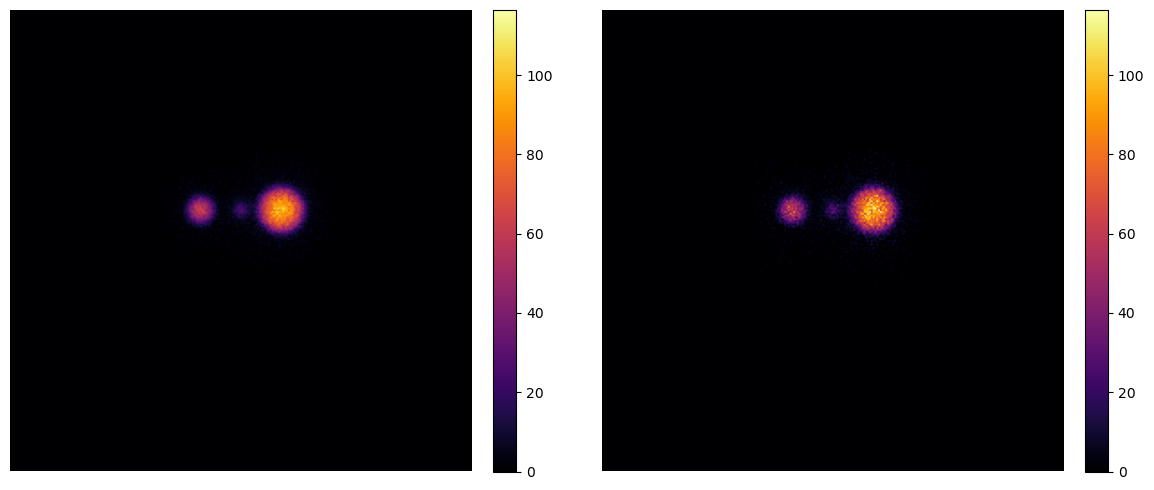

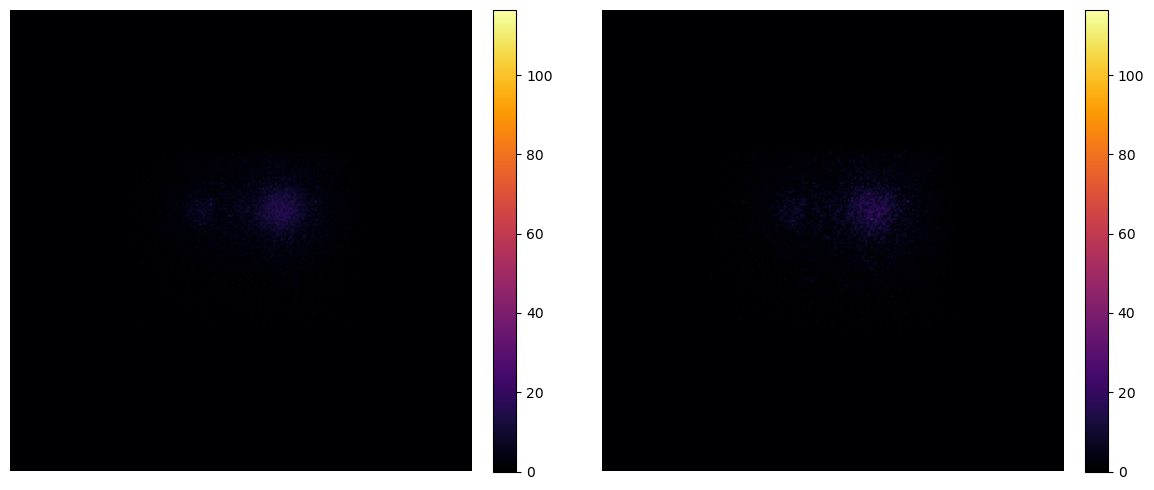

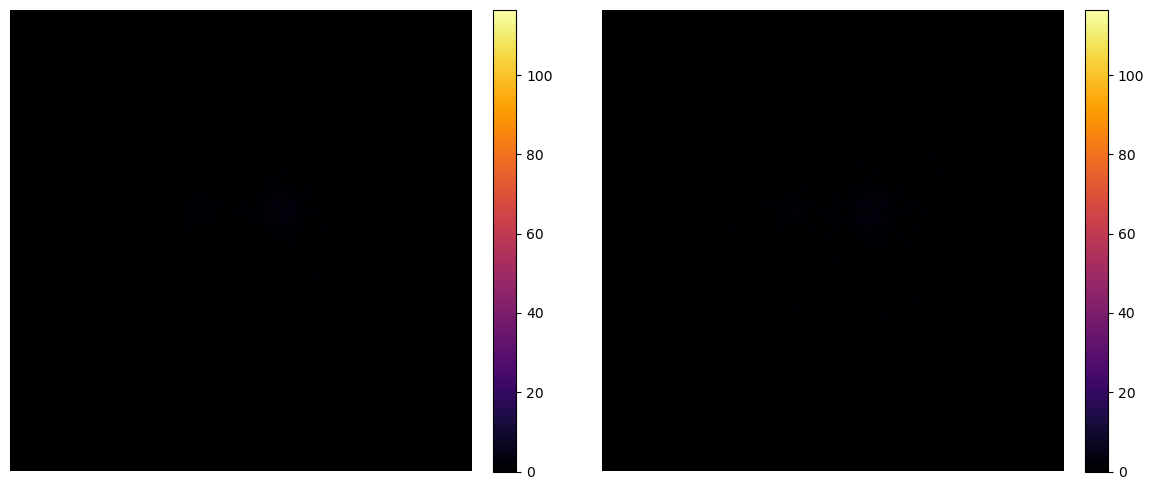

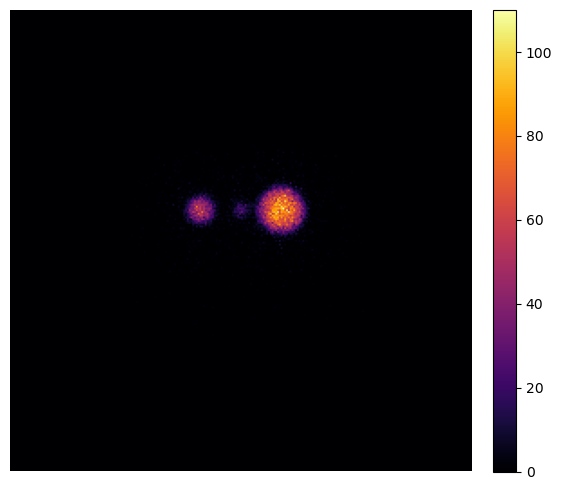

In [30]:
idx = (slice(None), 60, slice(None))
vmax = np.max(spect.AcquisitionData(str(pp_path)).as_array()[0,:])

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(pp_path)).as_array()[0,:], spect.AcquisitionData(str(pp_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc1_path)).as_array()[0,:], spect.AcquisitionData(str(sc1_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc2_path)).as_array()[0,:], spect.AcquisitionData(str(sc2_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=spect.AcquisitionData(str(tew_path)).as_array()[0,:],
    idx=idx
)